Name: Dagsan, Resty B.

Section: BSCPE 4-1

## CPE017 - Digital Signal Processing

This notebook contains code examples Module 1: Sounds and Signals

## Signal Processing Focus
* **Signal processing** involves synthesis, transformation, and analysis of signals.
* This course primarily focuses on **sound signals** but methods apply to various domains.
* The same methods work for electronic signals, mechanical vibrations, and more.
* Applicability extends to signals varying in space (e.g., elevation along a trail) and in multiple dimensions (e.g., images or movies).

## Periodic Signals
**Periodic signals** repeat their pattern after a specific time period.
Example: Striking a bell generates sound
This signal resembles a sinusoid, having the shape of a trigonometric sine function.

<div>
<img src="https://drive.google.com/uc?export=view&id=1Yixi1EBz61o_kYR88v51nkVY4oKWR5J9" width="500"/>
<figcaption>Fig.1.1 - Segment from a recording of a bell.</figcaption>
</div>

## Periodicity
The signal in the figure exhibits **periodicity**.
The graph displays three full cycles of repetition.
The duration of one cycle is the **period**, approximately 2.3 ms.

## Frequency
* Number of cycles per second
* **Inverse of the period**
* Units: Cycles per second or **Hertz (Hz)**


## Waveforms
Tuning forks produce sinusoidal waveforms due to simple harmonic motion.

Many musical instruments create periodic signals with more complex **waveforms**.

**Waveform shape** determines the **timbre** of the sound quality.
Complex waveforms evoke perceptions of **richness**, **warmth**, and **interest**.

<div>
<img src="https://drive.google.com/uc?export=view&id=1G01luGYxETQIfddtT4gBrA4uRP6q40Mv" width="500"/>
<figcaption>Fig.1.2 - Segment from a recording of a violin.</figcaption>
</div>

## Spectral Decomposition
* The most important topic in this course is **spectral decomposition**, which is the idea that any signal can be expressed as the sum of sinusoids with different frequencies.
* The most important mathematical idea in this course is the **discrete Fourier transform**, or **DFT**, which takes a signal and produces its spectrum.
* The **spectrum** is the set of sinusoids that add up to produce the signal.
* The most important algorithm in this course is the **Fast Fourier transform**, or **FFT**, which is an efficient way to compute the DFT.


<div>
<img src="https://drive.google.com/uc?export=view&id=1dsNRCChZV6s05b-13Phffv3jmmdpllbz" width="500"/>
<figcaption>Fig.1.2 - Segment from a recording of a violin.</figcaption>
</div>

This figure shows the spectrum of the violin recording. The x-axis is the range of frequencies that make up the signal. The y-axis shows the strength or **amplitude** of each frequency component.

* The lowest frequency component is called the **fundamental frequency**. The fundamental frequency of this signal is near 440 Hz (actually a little lower, or “flat”).
* In this signal the fundamental frequency has the largest amplitude, so it is also the **dominant frequency**.
* The other spikes in the spectrum are at frequencies 880, 1320, 1760, and 2200, which are integer multiples of the fundamental.
* These components are called **harmonics** because they are musically harmonious with the fundamental.



## Signals
* **thinkdsp.py** - contains classes and functions for working with signals and spectrums
* To represent signals, *thinkdsp* provides a class called *Signal*, which is the parent class for several signal types, including *Sinusoid*, which represents both sine and cosine signals



## Signals

Instantiate cosine and sine signals.

In [ ]:
from thinkdsp import CosSignal, SinSignal

cos_sig = CosSignal(freq=440, amp=1.0, offset=0)
sin_sig = SinSignal(freq=880, amp=0.5, offset=0)

* *freq* is frequency in Hz. *amp* is amplitude in unspecified units where 1.0 is defined as the largest amplitude we can record or play back.
* *offset* is a **phase offset** in radians. Phase offset determines where in the period the signal starts. For example, a sine signal with *offset=0* starts at sin 0, which is 0. With *offset=pi/2* it starts at sin π/2, which is 1.


Plot the sine and cosine signals.  By default, `plot` plots three periods.  

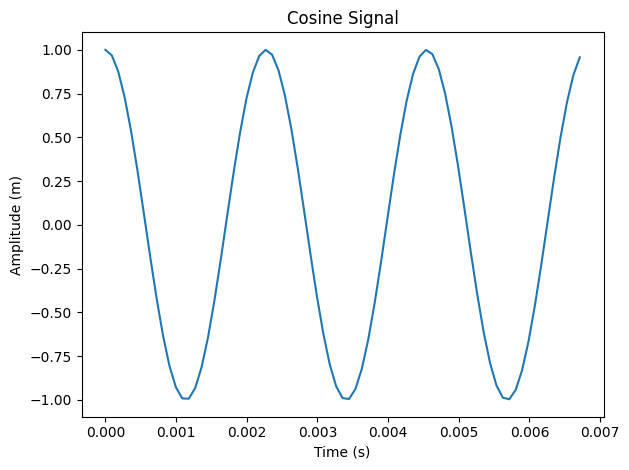

In [ ]:
from thinkdsp import decorate

cos_sig.plot()
decorate(xlabel='Time (s)', ylabel='Amplitude (m)', title='Cosine Signal')

Here's the sine signal.

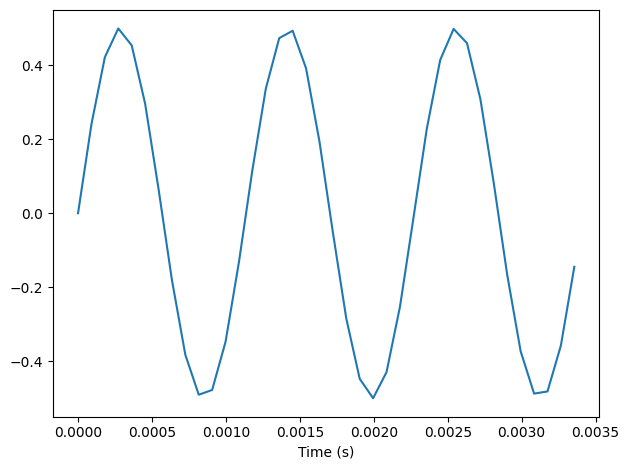

In [ ]:
sin_sig.plot()
decorate(xlabel='Time (s)')

Notice that the frequency of the sine signal is doubled, so the period is halved.

The sum of two signals is a SumSignal.

In [ ]:
mix = sin_sig + cos_sig
mix

Here's what it looks like.

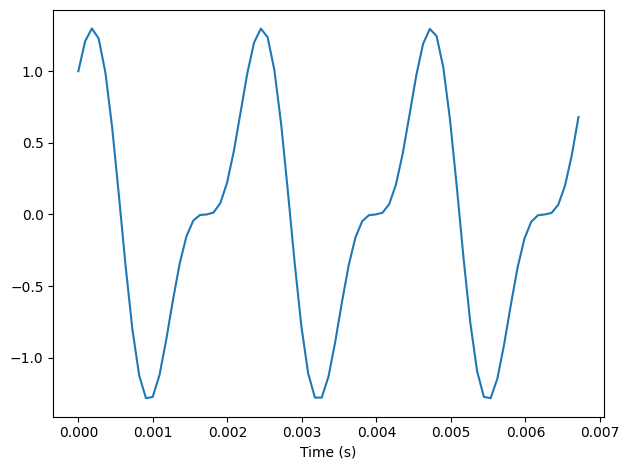

In [ ]:
mix.plot()
decorate(xlabel='Time (s)')

## Waves

* A `Signal` represents a mathematical function defined for all values of time.  If you evaluate a signal at a sequence of equally-spaced times, the result is a Wave.
* A `Wave` represents a signal evaluated at a sequence of points in time. Each point in time is called a `frame` (a term borrowed from movies and video).
* The measurement itself is called a `sample`, although “frame” and “sample” are sometimes used interchangeably.
* `framerate` is the number of samples per second.

In [ ]:
wave = mix.make_wave(duration=0.5, start=0, framerate=11025)
wave

* `duration` is the length of the Wave in seconds. `start` is the start time, also in seconds. `framerate` is the (integer) number of frames per second.
* `11,025` frames per second is one of several framerates commonly used in audio file formats, including Waveform Audio File (WAV) and mp3.
* This example evaluates the signal from `t=0` to `t=0.5` at 5,513 equally-spaced frames (because 5,513 is half of 11,025). The time between frames, or timestep, is `1/11025` seconds, about `91 µs`.


IPython provides an Audio widget that can play a wave.

In [ ]:
from IPython.display import Audio
audio = Audio(data=wave.ys, rate=wave.framerate)
audio

Wave also provides `make_audio()`, which does the same thing:

In [ ]:
wave.make_audio()

The `ys` attribute is a NumPy array that contains the values from the signal.  The interval between samples is the inverse of the framerate.

In [ ]:
print('Number of samples', len(wave.ys))
print('Timestep in ms', 1 / wave.framerate * 1000)

Number of samples 5512
Timestep in ms 0.09070294784580499


Signal objects that represent periodic signals have a `period` attribute.

Wave provides `segment`, which creates a new wave.  So we can pull out a 3 period segment of this wave.

In [ ]:
period = mix.period
segment = wave.segment(start=0, duration=period*3)
period

0.0022727272727272726

* *period* is a property of a Signal; it returns the period in seconds.
* *start* and *duration* are in seconds. This example copies the first three periods from *mix*. The result is a **Wave object**.

Wave provides `plot` method that uses `pyplot`.
pyplot is part of matplotlib; it is included in many Python distributions, or you might have to install it.

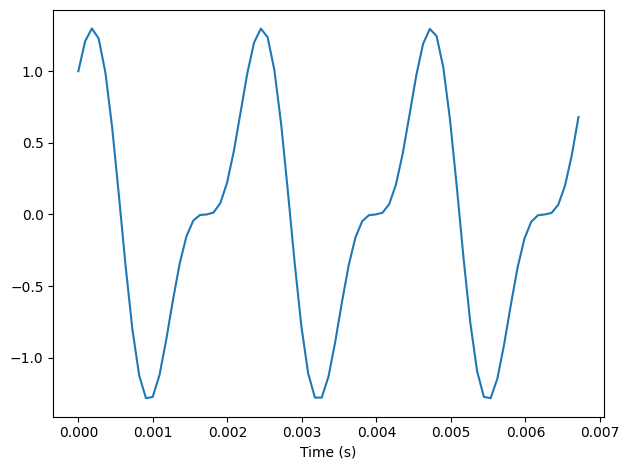

In [ ]:
segment.plot()
decorate(xlabel='Time (s)')

This signal contains two frequency components, so it is more complicated than the signal from the tuning fork, but less complicated than the violin.

`normalize` scales a wave so the range doesn't exceed -1 to 1.

`apodize` tapers the beginning and end of the wave so it doesn't click when you play it.

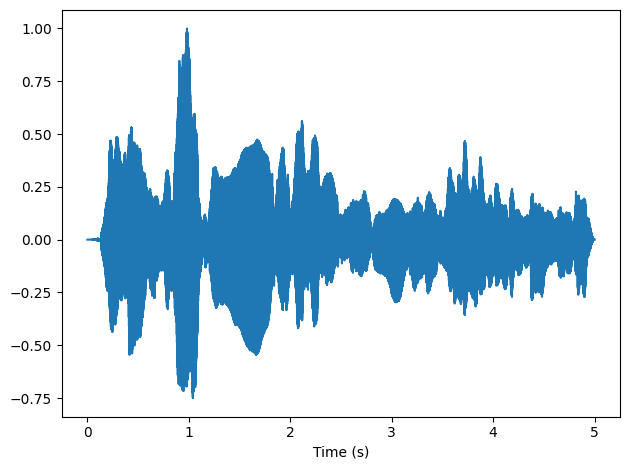

In [ ]:
wave.normalize()
wave.apodize()
wave.plot()
decorate(xlabel='Time (s)')

You can write a wave to a WAV file.

In [ ]:
wave.write('temp.wav')

Writing temp.wav


`wave.write` writes the wave to a file so it can be used by an exernal player.

In [ ]:
from thinkdsp import play_wave

play_wave(filename='temp.wav', player='aplay')

`read_wave` reads WAV files.  The WAV examples in the book are from freesound.org.  In the contributors section of the book, I list and thank the people who uploaded the sounds I use.

In [ ]:
filename = 'code_92002__jcveliz__violin-origional.wav'

In [ ]:
from thinkdsp import read_wave

wave = read_wave(filename)

In [ ]:
wave.make_audio()

I pulled out a segment of this recording where the pitch is constant.  When we plot the segment, we can't see the waveform clearly, but we can see the "envelope", which tracks the change in amplitude during the segment.

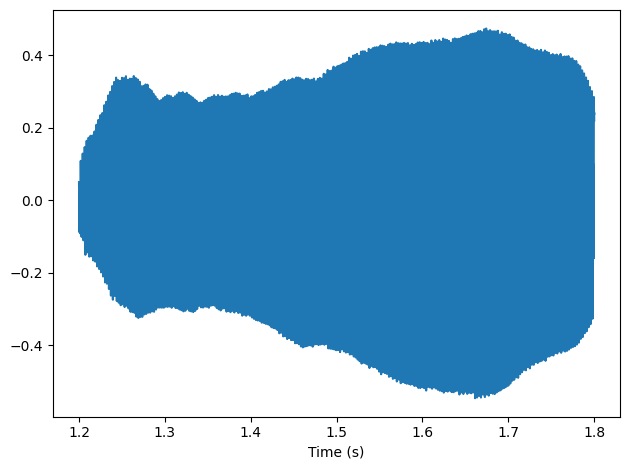

In [ ]:
start = 1.2
duration = 0.6
segment = wave.segment(start, duration)
segment.plot()
decorate(xlabel='Time (s)')

## Spectrums

Wave provides `make_spectrum`, which computes the spectrum of the wave.

In [ ]:
spectrum = segment.make_spectrum()

Spectrum provides `plot`

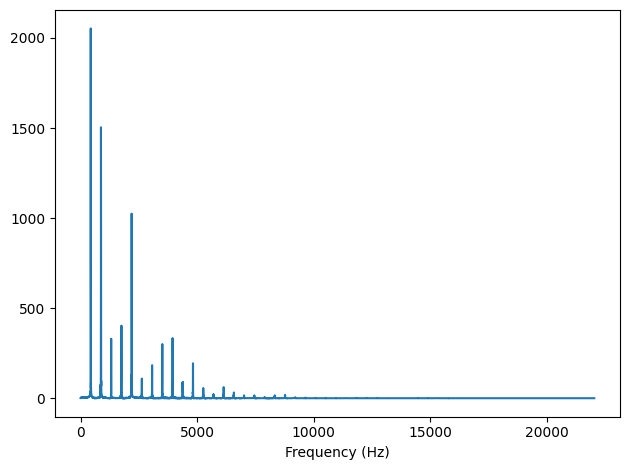

In [ ]:
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

The frequency components above 10 kHz are small.  We can see the lower frequencies more clearly by providing an upper bound:

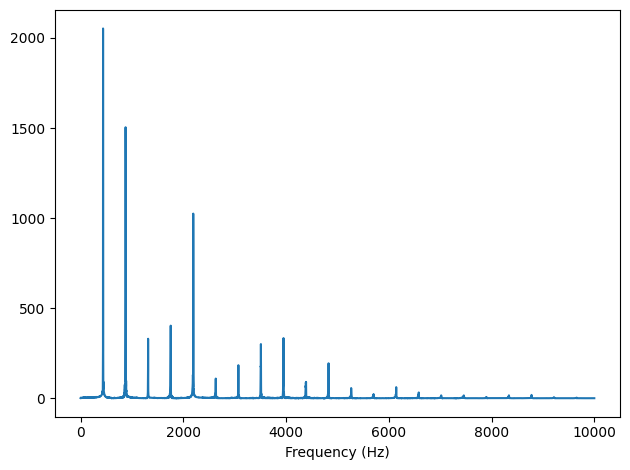

In [ ]:
spectrum.plot(high=10000)
decorate(xlabel='Frequency (Hz)')

Spectrum provides `low_pass`, which applies a low pass filter; that is, it attenuates all frequency components above a cutoff frequency.

In [ ]:
spectrum.low_pass(3000)

The result is a spectrum with fewer components.

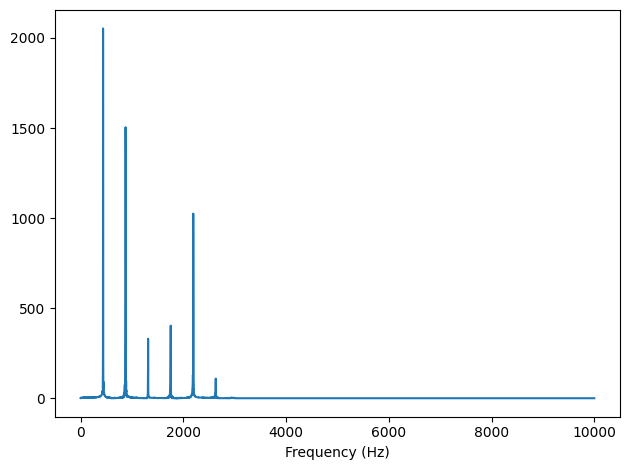

In [ ]:
spectrum.plot(high=10000)
decorate(xlabel='Frequency (Hz)')

We can convert the filtered spectrum back to a wave:

In [ ]:
filtered = spectrum.make_wave()

And then normalize it to the range -1 to 1.

In [ ]:
filtered.normalize()

Before playing it back, I'll apodize it (to avoid clicks).

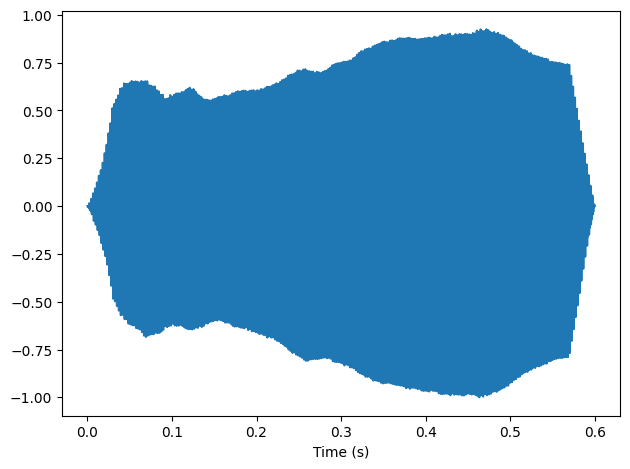

In [ ]:
filtered.apodize()
filtered.plot()
decorate(xlabel='Time (s)')

And I'll do the same with the original segment.

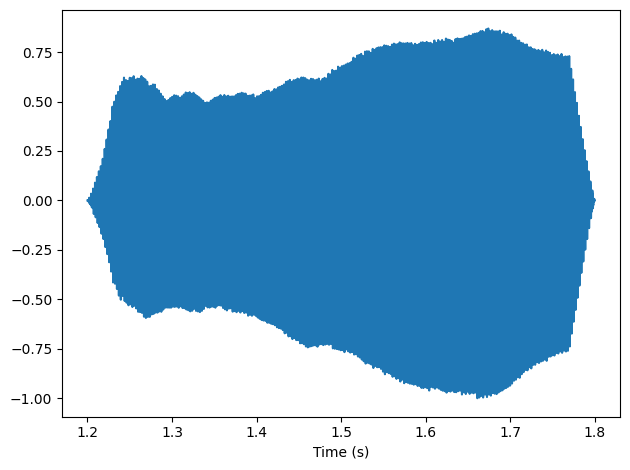

In [ ]:
segment.normalize()
segment.apodize()
segment.plot()
decorate(xlabel='Time (s)')

Finally, we can listen to the original segment and the filtered version.

In [ ]:
segment.make_audio()

In [ ]:
filtered.make_audio()

The original sounds more complex, with some high-frequency components that sound buzzy.
The filtered version sounds more like a pure tone, with a more muffled quality.  The cutoff frequency I chose, 3000 Hz, is similar to the quality of a telephone line, so this example simulates the sound of a violin recording played over a telephone.

## Interaction

The following example shows how to use interactive IPython widgets.

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

def filter_wave(wave, start, duration, cutoff):
    """Selects a segment from the wave and filters it.

    Plots the spectrum and displays an Audio widget.

    wave: Wave object
    start: time in s
    duration: time in s
    cutoff: frequency in Hz
    """
    segment = wave.segment(start, duration)
    spectrum = segment.make_spectrum()

    spectrum.plot(color='0.7')
    spectrum.low_pass(cutoff)
    spectrum.plot(color='#045a8d')
    decorate(xlabel='Frequency (Hz)')
    plt.show()

    audio = spectrum.make_wave().make_audio()
    display(audio)

Adjust the sliders to control the start and duration of the segment and the cutoff frequency applied to the spectrum.

In [ ]:
from ipywidgets import interact, fixed

wave = read_wave('code_92002__jcveliz__violin-origional.wav')
interact(filter_wave, wave=fixed(wave),
         start=(0, 5, 0.1), duration=(0, 5, 0.1), cutoff=(0, 10000, 100));

interactive(children=(FloatSlider(value=2.0, description='start', max=5.0), FloatSlider(value=2.0, description…

Conclusion:
****

First and foremost, I learned that to make the production and processing of digital signals, such as sine and cosine waves, easier, the thinkdsp library is required. For signal processing tasks, the CosSignal and SinSignal classes offer a simple method of generating these signals with certain parameters, which makes them effective. Other than that, libraries can also be used to streamline the coding process, as they can still be used in other cells. For instance, using the decorate function from the thinkdsp library allows us to easily label plots for both cosine and sine signals across different cells.

Each signal is being generated with three important parameters. With that being said, parameters must be established. Frequency is needed to control the pitch or rate of oscillation in a signal. Amplitude and offset are needed to adjust the signal's strength and phase, which affect its intensity and how it combines with other signals.

In terms of the signal to be analyzed, we must create a wave. To create the wave, we can use the mix.make_method. And since this is still a signal, we must also establish the parameters that serve a specific purpose. To be specific, framerate with the value of 11205  to establish the sample rate per second, which affects the audio signal's fidelity and quality. It is also a given fact that this value for frame rate is typically used in audio file formats. After creating the wave, we can also listen to it, and it is up to us to decide the duration of this wave based on the parameters we decided to establish.

Moving on to the len method, we can get the number of samples, followed by the time step by 1 dividing to the value of frame rate and multiplying by 1000. In terms of period, once it is determined, it can be used to calculate the duration needed for any desired number of cycles. The segment method then extracts that specific duration from the wave, allowing you to work with a defined portion of the signal. Apodizing it means it smoothes the wave's beginning and end to eliminate clicking sounds during playback, while normalizing adjusts  a wave's amplitude to a range of -1 to 1. It is not to worry about if the visual representation of the signal is thick like a solid color background. The reason for this circumstance is that it now contains a lot of cycles.

The wave can also be converted to wav file format and we can also upload it to analyze. An audio wave file is read in order to extract a 0.6-second piece that begins at 1.2 seconds and has a constant pitch. The "envelope" shows amplitude variations throughout the segment, even though the waveform may not be visible when plotted. As previously mentioned, it is because it contains many cycles within the short duration of the segment (0.6 seconds). The frequency components of a wave can be shown using the make_spectrum method, which can be tuned to emphasize lower frequencies. Higher frequencies are attenuated by the use of the low_pass filter, producing a sound quality. In terms of noise canceling, all I know is that two opposite signals are just canceling each other. However, in order to lessen undesired background noise, filtering techniques—such as low-pass filters—are also utilized in noise cancellation. For instance, if you are filtering out high-frequency noise in a violin recording, you could set a low-pass filter with a cutoff frequency of 5 kHz to remove unwanted high-frequency sounds while preserving the natural tones of the violin.






